# Gráficos que serão desenvolvidos 

- [Gráfico 1](#gr1): taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


- [Gráfico 2](#gr2): Taxa de utilização de Espaço da Rede: que é quão bem a abordagem está aproveitando o espaço de armazenamento disponível após uma falha na rede. Uma taxa alta indica uma boa utilização dos recursos 

- [Gráfico 3](#gr3): -Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele


- [Gráfico 4](#gr4): - tempo de realocação

### Configuração inicial

Importando bibliotecas necessárias

In [1]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd 
import seaborn as sns
#import plotly.graph_objects as go
import numpy as np
#import plotly.io as pio
#import plotly.express as px


import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

### Carregamento dos dados

In [2]:
results_flows_directories = glob.glob('../../results/results_flows*/*') # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\goku_backup_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\goku_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\msf_s_50_p_5_sfc_on_rel_1',
 '../../results\\results_flows\\musfico_s_50_p_5_sfc_on_rel_1']

Teste o 'for' abaixo e verifique se o alg_name aparece corretamente. Caso não apareça, provavelmente é porque sua máquina está lendo arquivos de forma diferente. Altere a linha do alg_name na função 'collect_data_from_alg_directory()' até que apareça corretamente. Você pode testar o loop abaixo, que é o mesmo que está inicialmente na função função 'collect_data_from_alg_directory()'

In [3]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split('/')[-1].split('_')
    
    if simu_exec_name [2] == 'backup':
        alg_name = 'goku_backup'
    else:
        alg_name = simu_exec_name[1].split(f'\\')[1]
    reliability = simu_exec_name[-1]

In [4]:
aggregated_simulation_data = pd.DataFrame() 
algos = {}
def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split('/')[-1].split('_')
        
        if simu_exec_name [2] == 'backup':
            alg_name = 'goku_backup'
        else:
            alg_name = simu_exec_name[1].split(f'\\')[1]

        if alg_name == 'g':
            alg_name = 'Greedy'
        if alg_name == 'ga':
            alg_name =  'GA'
        if alg_name == 'msf':
            alg_name = 'MSF'
        if alg_name == 'goku':
            alg_name = 'OSCIM'
        if alg_name == 'goku_backup':
            alg_name = 'Backup OSCIM'
        if alg_name == 'musfico':
            alg_name = 'MuSFiCO'

        files = os.listdir(alg_dir)
        #print(f"Simulação: {alg_name}, {reliability}") 
        #print("Quantidade de csv: ", len(files))
        
        if alg_name not in log_simu:
            log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
        else:

            log_simu[alg_name]['files'] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                #print(simulation_df)
                sfc_id_values = simulation_df['sfc_id'].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = 'sfc_cache_p4_50' in simulation_df['sfc_id'].values
            
            if simulation_is_success: 
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]
    
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df['algorithm'] = alg_name
                simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']
                
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]['simulacoes_sucesso'] += 1
                log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()
        
    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [5]:
metricas_coleta = [
    "time_seconds",
    "cpu_utilization",
    "bandwidth_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "sfc_id",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed","latency_diff","wait_time",'cpu_saved','shared_vnfs','users'
]

concatenate_simulation_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)


Resumo das Simulações:
Algoritmo: Backup OSCIM
  Quantidade de arquivos: 30
  Simulações de sucesso: 28
  Dados nulos: 118742

Algoritmo: OSCIM
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 94764

Algoritmo: MSF
  Quantidade de arquivos: 30
  Simulações de sucesso: 29
  Dados nulos: 83342

Algoritmo: MuSFiCO
  Quantidade de arquivos: 30
  Simulações de sucesso: 30
  Dados nulos: 87817



In [6]:
concatenate_simulation_data

,time_seconds,cpu_utilization,bandwidth_utilization,latency,decision_time_ms,success,sfc_id,crash_moment,recovery_time,sfc_recovered,...,running_players,running_sessions,users_crashed,latency_diff,wait_time,cpu_saved,shared_vnfs,users,algorithm,simulation
0,0.0,0.0083,0.0009,1.0,7.579,1,sfc_cache_p1_1,0,NaN,NaN,...,1,1,0,NaN,NaN,0.000000,0,1,Backup OSCIM,0
1,0.0,0.0258,0.0028,1.0,3.834,1,sfc_unique_p1_1,0,NaN,NaN,...,1,1,0,NaN,NaN,0.000000,1,1,Backup OSCIM,0
2,0.1,0.0272,0.0037,1.0,2.704,1,sfc_cache_p2_1,0,NaN,NaN,...,2,1,0,NaN,NaN,8.333333,4,2,Backup OSCIM,0
3,0.1,0.0447,0.0055,1.0,2.706,1,sfc_unique_p2_1,0,NaN,NaN,...,2,1,0,NaN,NaN,8.333333,5,2,Backup OSCIM,0
4,0.1,0.0531,0.0074,2.0,2.677,1,sfc_cache_p3_1,0,NaN,NaN,...,3,1,0,NaN,NaN,8.333333,5,3,Backup OSCIM,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,996.7,0.3804,0.2009,1.0,69.994,1,sfc_unique_p2_50,0,NaN,NaN,...,23,6,4,NaN,NaN,79.333333,46,247,MuSFiCO,29
736,996.8,0.3816,0.2018,1.0,64.100,1,sfc_cache_p3_50,0,NaN,NaN,...,24,6,4,NaN,NaN,87.666667,49,248,MuSFiCO,29
737,997.0,0.3749,0.1917,1.0,92.891,1,sfc_unique_p3_50,0,NaN,NaN,...,23,5,4,NaN,NaN,87.666667,50,248,MuSFiCO,29
738,997.1,0.3760,0.1926,1.0,63.688,1,sfc_cache_p4_50,0,NaN,NaN,...,24,5,4,NaN,NaN,96.000000,53,249,MuSFiCO,29


In [7]:
data = concatenate_simulation_data.groupby(['algorithm', 'simulation'])

Função De Plot

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

def plot_metric_by_algorithm(data, metric, title, output_boxplot='boxplot.pdf', output_barplot='barplot.pdf', output_combined='combined_plot.pdf', save_individual=True):
    """
    Gera subplots com boxplot e barplot de uma métrica específica agrupada por algoritmo.
    
    Parâmetros:
    - data: DataFrame contendo os dados
    - metric: string, nome da métrica a ser plotada
    - title: string, título para os gráficos
    - output_boxplot: string, nome do arquivo para salvar o boxplot (default: 'boxplot.pdf')
    - output_barplot: string, nome do arquivo para salvar o barplot (default: 'barplot.pdf')
    - output_combined: string, nome do arquivo para salvar o plot combinado (default: 'combined_plot.pdf')
    - save_individual: boolean, se True, salva os plots individualmente e exibe o subplot; se False, salva e exibe apenas o subplot combinado.
    """
    # Cria a pasta de saída se não existir
    output_folder = "results"
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    output_combined = f'{metric}_plot.pdf'

    # Define os caminhos completos para salvar os arquivos
    boxplot_path = os.path.join(output_folder, output_boxplot)
    barplot_path = os.path.join(output_folder, output_barplot)
    combined_path = os.path.join(output_folder, output_combined)
    
    # Ordem dos algoritmos e cores correspondentes
    algorithms_order = ['Backup OSCIM', 'OSCIM', 'MSF', 'MuSFiCO']
    colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'plum']
    
    # Criação dos subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot do Boxplot no primeiro subplot
    sns.boxplot(x='algorithm', y=metric, data=data, 
                palette=dict(zip(algorithms_order, colors)), 
                order=algorithms_order, ax=axes[0])
    axes[0].set_title(f'{title} - Boxplot')
    axes[0].set_xlabel('Algorithm')
    axes[0].set_ylabel(title)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Cálculo da média e do desvio padrão para o barplot
    mean_rates = data.groupby('algorithm')[metric].mean()
    std_rates = data.groupby('algorithm')[metric].std()
    
    # Plot do Barplot no segundo subplot
    axes[1].bar(algorithms_order, mean_rates[algorithms_order], yerr=std_rates[algorithms_order], 
                capsize=5, color=colors, edgecolor='black')
    axes[1].set_title(f'{title} - Barplot')
    axes[1].set_xlabel('Algorithm')
    axes[1].set_ylabel(title)
    axes[1].set_ylim(0, max(mean_rates + std_rates) * 1.1)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajustar layout
    plt.tight_layout()

    # Salvar os gráficos conforme a escolha do usuário
    if save_individual:
        # Salvar os gráficos individuais "nos bastidores"
        fig_individual, ax = plt.subplots(figsize=(8, 6))
        sns.boxplot(x='algorithm', y=metric, data=data, 
                    palette=dict(zip(algorithms_order, colors)), 
                    order=algorithms_order, ax=ax)
        ax.set_title(f'{title} - Boxplot')
        ax.set_xlabel('Algorithm')
        ax.set_ylabel(title)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        fig_individual.savefig(boxplot_path)
        plt.close(fig_individual)  # Fechar o plot individual após salvar

        fig_individual, ax = plt.subplots(figsize=(8, 6))
        ax.bar(algorithms_order, mean_rates[algorithms_order], yerr=std_rates[algorithms_order], 
               capsize=5, color=colors, edgecolor='black')
        ax.set_title(f'{title} - Barplot')
        ax.set_xlabel('Algorithm')
        ax.set_ylabel(title)
        ax.set_ylim(0, max(mean_rates + std_rates) * 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        fig_individual.savefig(barplot_path)
        plt.close(fig_individual)  # Fechar o plot individual após salvar

        # Mostrar apenas o subplot combinado
        fig.savefig(combined_path)
        plt.show()
    else:
        # Salvar e mostrar o subplot combinado
        fig.savefig(combined_path)
        plt.show()

# Exemplo de uso:
# plot_metric_by_algorithm(df, 'cpu_utilization', 'CPU Utilization (%)', 'cpu_utilization_boxplot.pdf', 'cpu_utilization_barplot.pdf', 'cpu_utilization_combined.pdf', save_individual=True)


# Gráfico 1 <a id="gr1"></a>

taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


In [9]:
import pandas as pd

# Exemplo de função de cálculo de média
def calculate_mean(group):
    return group.mean()

recovered_rate_mean_values = data['sfc_recovered'].apply(calculate_mean).reset_index()
recovered_rate_mean_values = recovered_rate_mean_values.rename(columns={0: 'sfc_recovered'})
df_recovered_sfcs = recovered_rate_mean_values[['algorithm', 'simulation', 'sfc_recovered']]
print(df_recovered_sfcs)


        algorithm  simulation  sfc_recovered
0    Backup OSCIM           0            1.0
1    Backup OSCIM           1            1.0
2    Backup OSCIM           2            NaN
3    Backup OSCIM           3            1.0
4    Backup OSCIM           4            NaN
..            ...         ...            ...
112         OSCIM          25            1.0
113         OSCIM          26            1.0
114         OSCIM          27            1.0
115         OSCIM          28            1.0
116         OSCIM          29            1.0

[117 rows x 3 columns]


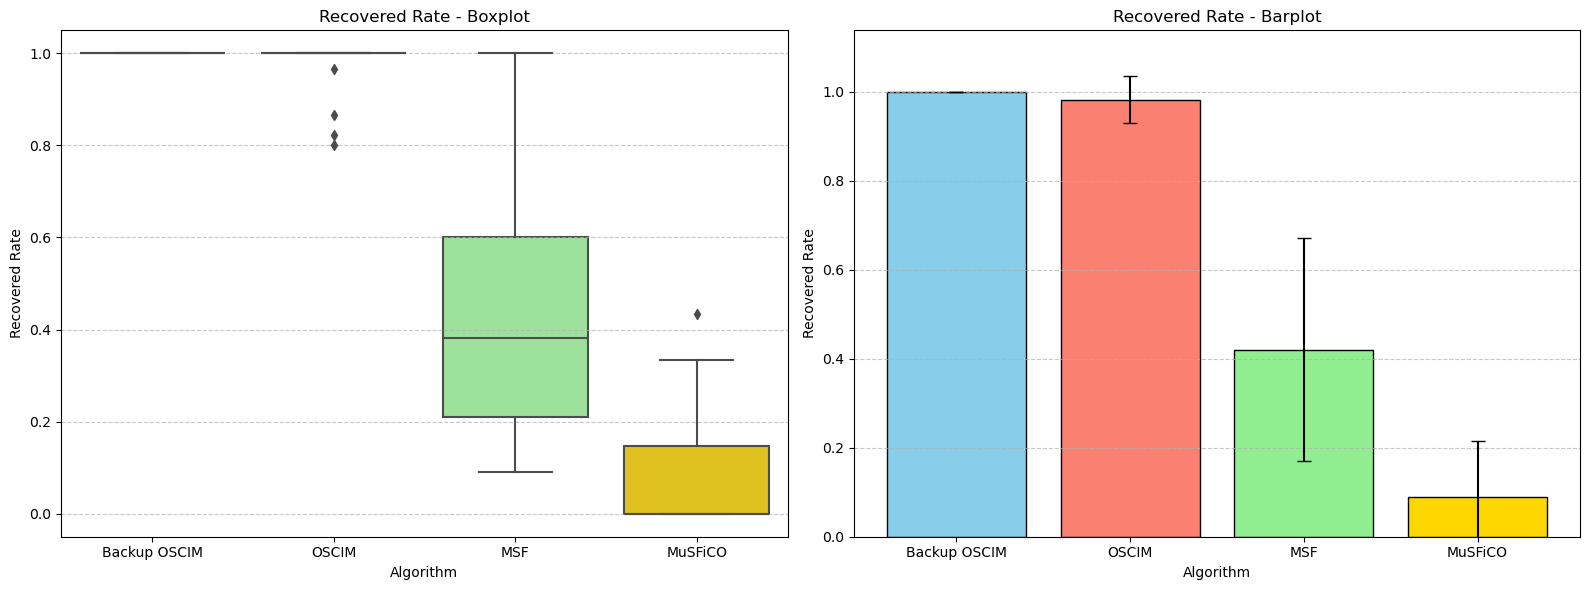

In [10]:
plot_metric_by_algorithm(df_recovered_sfcs, 'sfc_recovered', 'Recovered Rate', 'recovered_rate_boxplot.pdf', 'recovered_rate_barplot.pdf')

# Gráfico 2 Recovery Time <a id="gr2"></a>

Recovery time é muito parecido, porém a diferença é que nós não queremos coletar casos onde a sfc não conseguiu ser recuperada

In [11]:
import pandas as pd

# Exemplo de função de cálculo de média
def calculate_mean(group):
    return group.mean()

recovered_time_mean_values = data['recovery_time'].apply(calculate_mean).reset_index()
df_time_sfcs = recovered_time_mean_values[['algorithm', 'simulation', 'recovery_time']]

print(df_time_sfcs)


        algorithm  simulation  recovery_time
0    Backup OSCIM           0       0.000000
1    Backup OSCIM           1       0.000000
2    Backup OSCIM           2            NaN
3    Backup OSCIM           3       0.000000
4    Backup OSCIM           4            NaN
..            ...         ...            ...
112         OSCIM          25       0.396009
113         OSCIM          26       0.280485
114         OSCIM          27       1.355557
115         OSCIM          28       0.328569
116         OSCIM          29       0.560971

[117 rows x 3 columns]


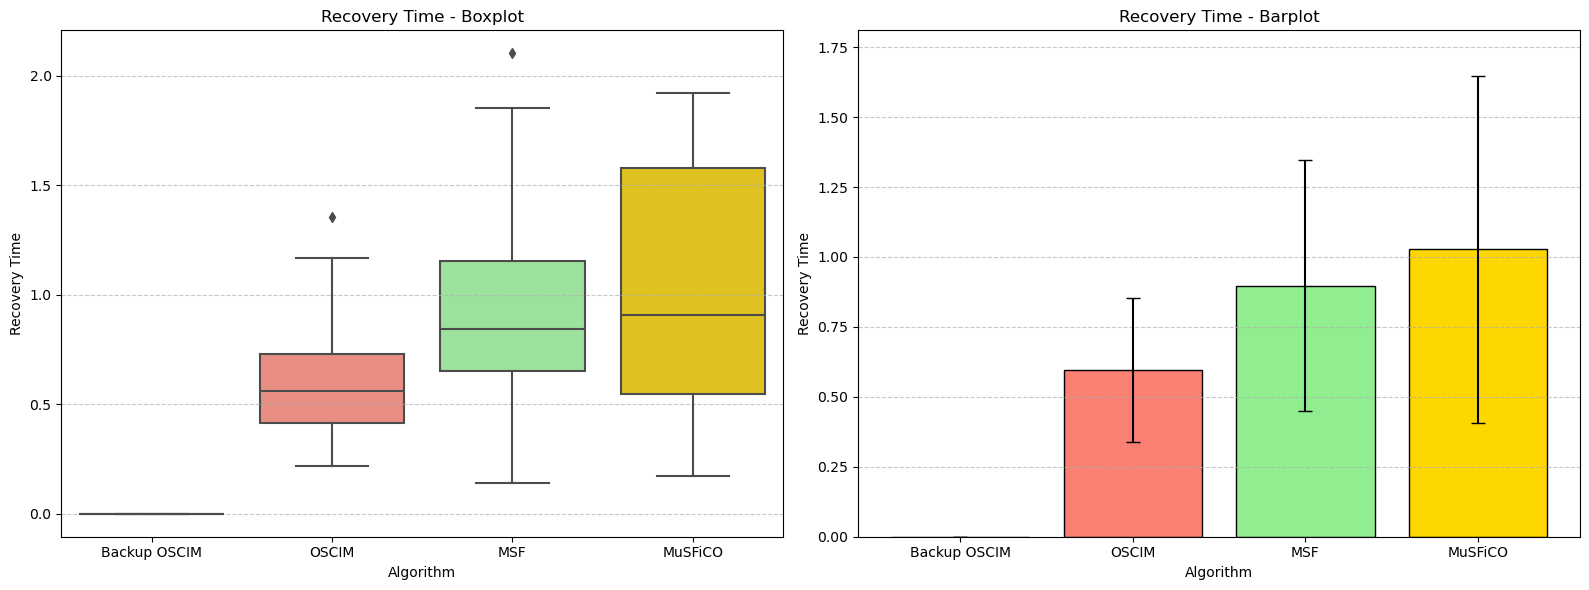

In [12]:
plot_metric_by_algorithm(df_time_sfcs, 'recovery_time', 'Recovery Time', 'recovery_time_boxplot.pdf', 'recovery_time_barplot.pdf')

# Gráfico 3 - latency diff

In [13]:
latency_diff_mean_values = data['latency_diff'].apply(calculate_mean).reset_index()
df_latency_diff = latency_diff_mean_values[['algorithm', 'simulation', 'latency_diff']]


# Supondo que o DataFrame original seja chamado 'df'
# Definir os valores mínimo e máximo
min_value = -6
max_value = 6

# Criar uma nova coluna com a normalização
df_latency_diff['normalized_latency_diff'] = (df_latency_diff['latency_diff'] - min_value) / (max_value - min_value)

# Exibir o DataFrame resultante com a nova coluna
df_latency_diff

,algorithm,simulation,latency_diff,normalized_latency_diff
0,Backup OSCIM,0,-0.500000,0.458333
1,Backup OSCIM,1,-0.500000,0.458333
2,Backup OSCIM,2,NaN,NaN
3,Backup OSCIM,3,-0.333333,0.472222
4,Backup OSCIM,4,NaN,NaN
...,...,...,...,...
112,OSCIM,25,0.923077,0.576923
113,OSCIM,26,0.428571,0.535714
114,OSCIM,27,0.136364,0.511364
115,OSCIM,28,0.833333,0.569444


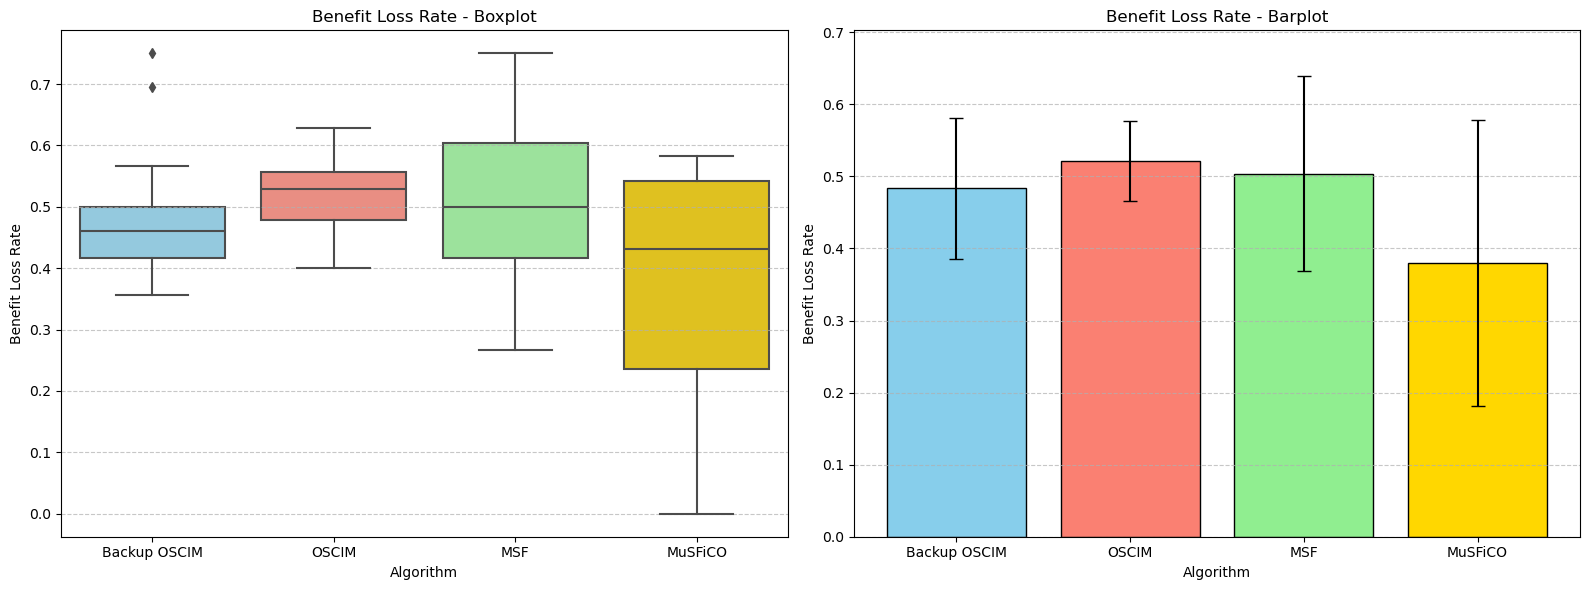

In [14]:
plot_metric_by_algorithm(df_latency_diff, 'normalized_latency_diff', 'Benefit Loss Rate', 'benefit_loss_rate_boxplot.pdf', 'benefit_loss_rate_barplot.pdf')

# Gráfico 4 Wait time <a id="gr3"></a>

In [15]:
# wait_time_mean_values = data.apply(calculate_mean, 'wait_time').reset_index(name='wait_time')
# df_wait_time_sfcs = wait_time_mean_values[['algorithm', 'simulation', 'wait_time']]
# df_wait_time_sfcs

In [16]:
# plot_metric_by_algorithm(df_wait_time_sfcs, 'wait_time', 'Time with High Latency', 'wait_time_boxplot.pdf', 'wait_time_barplot.pdf')

# Gráfico 5 - Acceptance <a id="gr5"></a>

In [17]:
import pandas as pd

# Supondo que o DataFrame original seja chamado 'concatenate_simulation_data' e contenha as colunas 'sfc_id' e 'algorithm'
# Criar uma função que verifica se a SFC é de backup
def is_backup(row):
    session_number = int(row['sfc_id'].split('_')[-1])  # Obtém o número da sessão
    algorithm_is_backup = row['algorithm'].startswith('Backup')  # Verifica se o algoritmo começa com 'Backup'
    return session_number % 2 == 0 and algorithm_is_backup  # True se a sessão for par e o algoritmo for de backup

concatenate_simulation_data['backup_sfc'] = concatenate_simulation_data.apply(is_backup, axis=1)

# Filtrar para selecionar apenas as SFCs que não são de backup
non_backup_sfcs = concatenate_simulation_data[~concatenate_simulation_data['backup_sfc']]

# Exibir o DataFrame resultante sem as SFCs de backup
non_backup_sfcs = non_backup_sfcs.groupby(['algorithm','simulation'])


success_mean_values = non_backup_sfcs['success'].apply(calculate_mean).reset_index()
df_success_sfcs = success_mean_values[['algorithm', 'simulation', 'success']]


df_success_sfcs

,algorithm,simulation,success
0,Backup OSCIM,0,0.958217
1,Backup OSCIM,1,0.989957
2,Backup OSCIM,2,0.969834
3,Backup OSCIM,3,0.978689
4,Backup OSCIM,4,0.990491
...,...,...,...
112,OSCIM,25,0.952442
113,OSCIM,26,0.944809
114,OSCIM,27,0.943878
115,OSCIM,28,0.963370


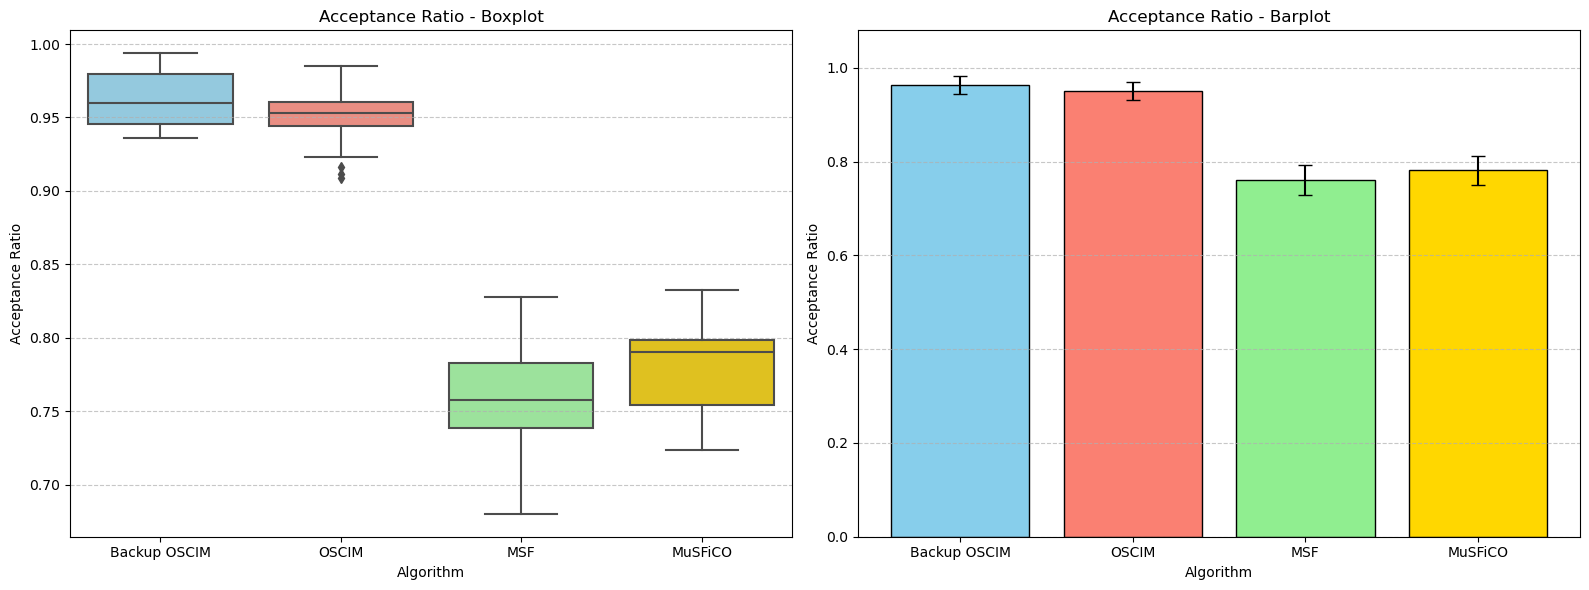

In [18]:
plot_metric_by_algorithm(df_success_sfcs, 'success', 'Acceptance Ratio', 'sucess_boxplot.pdf', 'sucess_barplot.pdf')

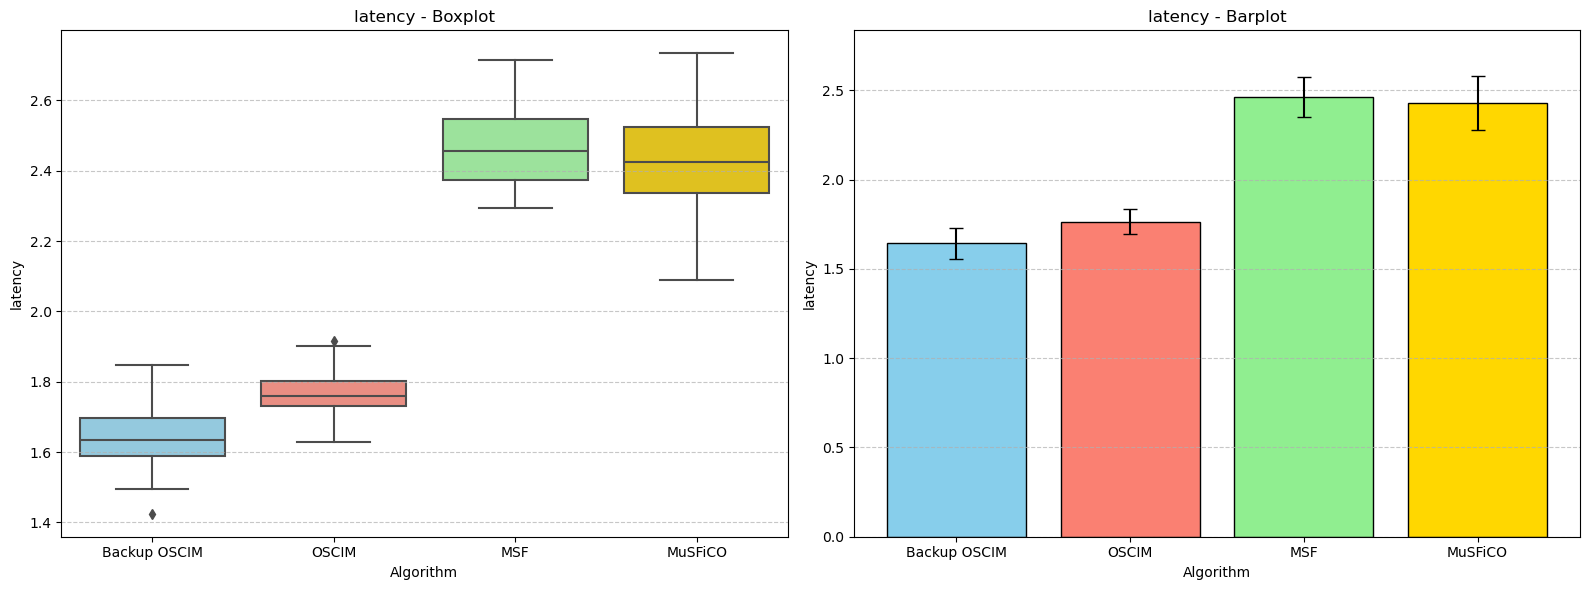

In [19]:
latency_mean_values = data['latency'].apply(calculate_mean).reset_index()
df_latency_sfcs = latency_mean_values[['algorithm', 'simulation', 'latency']]

plot_metric_by_algorithm(df_latency_sfcs, 'latency', 'latency', 'latency_boxplot.pdf', 'latency_barplot.pdf')

# Métricas Clássicas

ACEITAÇÃO

CPU
CPU/PER FLOW

BANDA
BANDA/PER FLOW

REÚSO
REÚSO PER FLOW

Latência

Decision Time

In [20]:
concatenate_simulation_data

,time_seconds,cpu_utilization,bandwidth_utilization,latency,decision_time_ms,success,sfc_id,crash_moment,recovery_time,sfc_recovered,...,running_sessions,users_crashed,latency_diff,wait_time,cpu_saved,shared_vnfs,users,algorithm,simulation,backup_sfc
0,0.0,0.0083,0.0009,1.0,7.579,1,sfc_cache_p1_1,0,NaN,NaN,...,1,0,NaN,NaN,0.000000,0,1,Backup OSCIM,0,False
1,0.0,0.0258,0.0028,1.0,3.834,1,sfc_unique_p1_1,0,NaN,NaN,...,1,0,NaN,NaN,0.000000,1,1,Backup OSCIM,0,False
2,0.1,0.0272,0.0037,1.0,2.704,1,sfc_cache_p2_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,4,2,Backup OSCIM,0,False
3,0.1,0.0447,0.0055,1.0,2.706,1,sfc_unique_p2_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,5,2,Backup OSCIM,0,False
4,0.1,0.0531,0.0074,2.0,2.677,1,sfc_cache_p3_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,5,3,Backup OSCIM,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,996.7,0.3804,0.2009,1.0,69.994,1,sfc_unique_p2_50,0,NaN,NaN,...,6,4,NaN,NaN,79.333333,46,247,MuSFiCO,29,False
736,996.8,0.3816,0.2018,1.0,64.100,1,sfc_cache_p3_50,0,NaN,NaN,...,6,4,NaN,NaN,87.666667,49,248,MuSFiCO,29,False
737,997.0,0.3749,0.1917,1.0,92.891,1,sfc_unique_p3_50,0,NaN,NaN,...,5,4,NaN,NaN,87.666667,50,248,MuSFiCO,29,False
738,997.1,0.3760,0.1926,1.0,63.688,1,sfc_cache_p4_50,0,NaN,NaN,...,5,4,NaN,NaN,96.000000,53,249,MuSFiCO,29,False


## Métricas que não precisam de ajuste
- CPU
- BANDA
- decision_time_ms

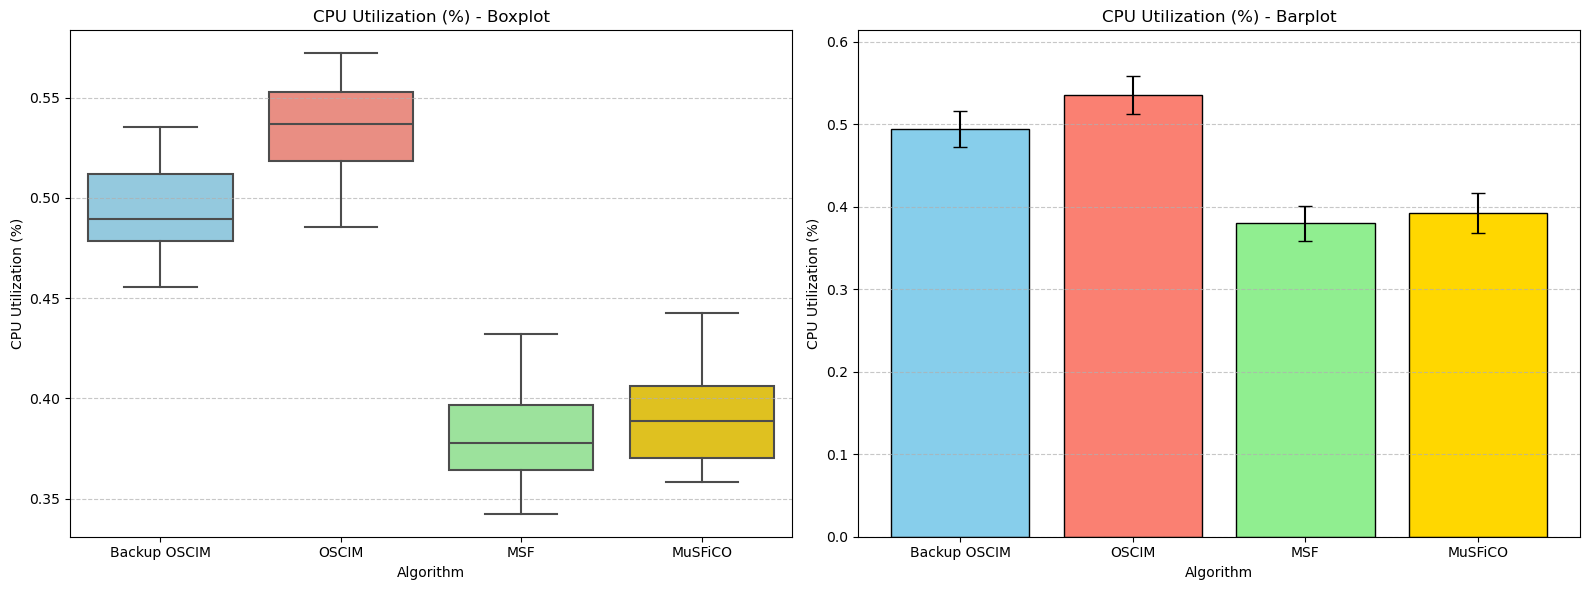

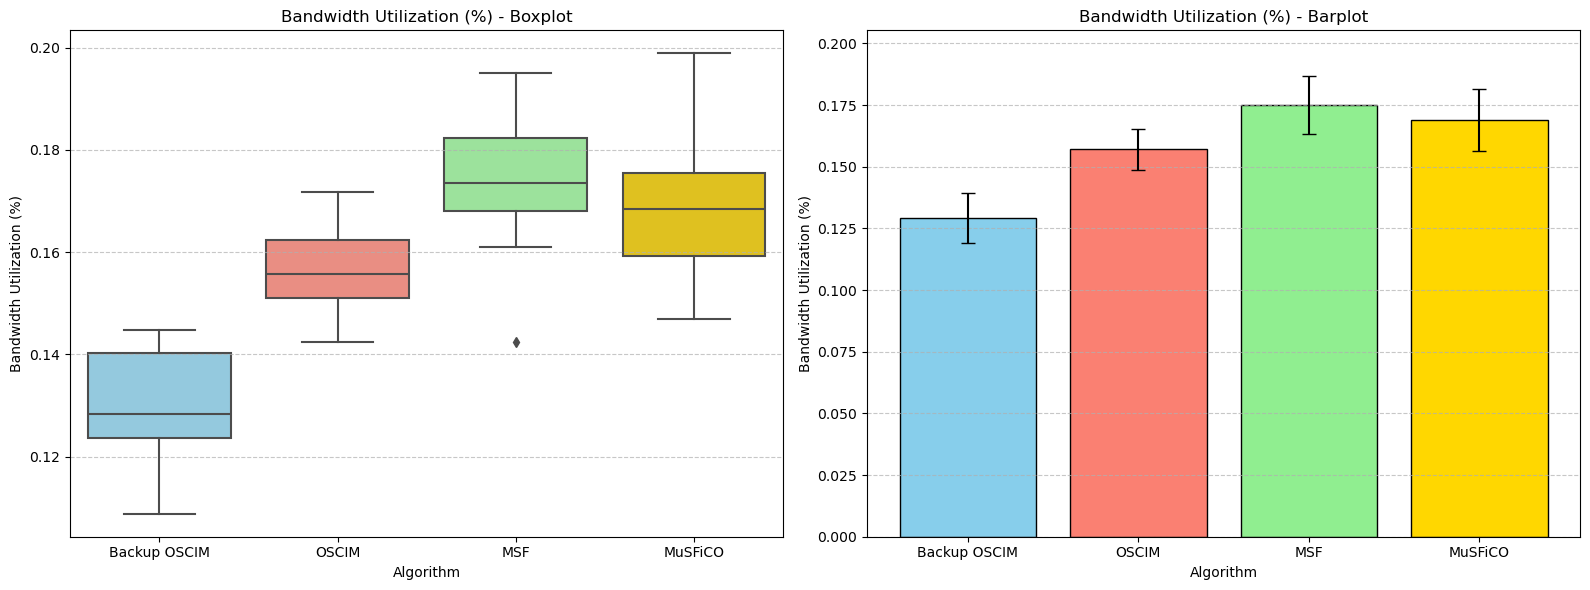

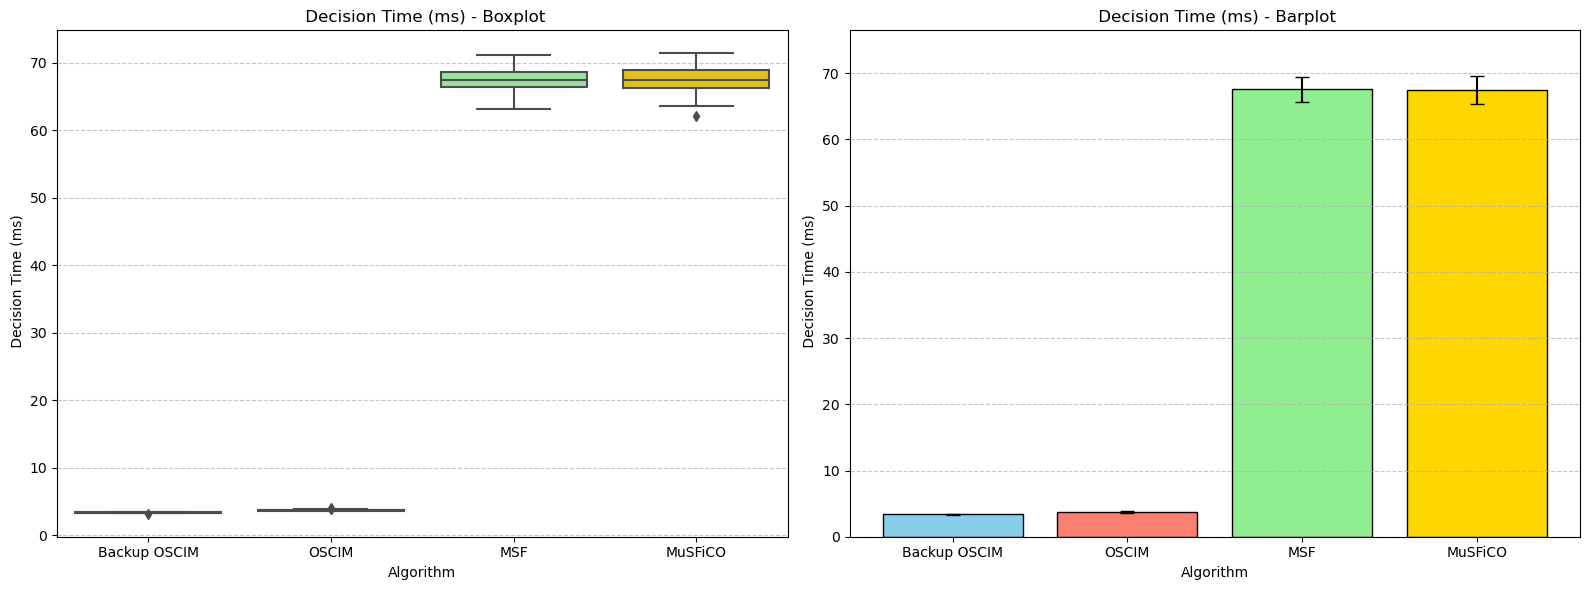

In [21]:
consume_metrics = concatenate_simulation_data[['cpu_utilization', 'bandwidth_utilization','cpu_saved','shared_vnfs','simulation','decision_time_ms','algorithm']]

df_consume_metrics = consume_metrics.groupby(['algorithm','simulation']).mean().reset_index()

# Lista de métricas e seus títulos correspondentes
metrics = [
    ('cpu_utilization', 'CPU Utilization (%)'),
    ('bandwidth_utilization', 'Bandwidth Utilization (%)'),
    ('decision_time_ms',' Decision Time (ms)')
]

# Loop para gerar gráficos para cada métrica
for metric, title in metrics:
    boxplot_filename = f'{metric}_boxplot.pdf'
    barplot_filename = f'{metric}_barplot.pdf'
    
    plot_metric_by_algorithm(df_consume_metrics, metric, title, boxplot_filename, barplot_filename)

In [22]:
consume_metrics

,cpu_utilization,bandwidth_utilization,cpu_saved,shared_vnfs,simulation,decision_time_ms,algorithm
0,0.0083,0.0009,0.000000,0,0,7.579,Backup OSCIM
1,0.0258,0.0028,0.000000,1,0,3.834,Backup OSCIM
2,0.0272,0.0037,8.333333,4,0,2.704,Backup OSCIM
3,0.0447,0.0055,8.333333,5,0,2.706,Backup OSCIM
4,0.0531,0.0074,8.333333,5,0,2.677,Backup OSCIM
...,...,...,...,...,...,...,...
735,0.3804,0.2009,79.333333,46,29,69.994,MuSFiCO
736,0.3816,0.2018,87.666667,49,29,64.100,MuSFiCO
737,0.3749,0.1917,87.666667,50,29,92.891,MuSFiCO
738,0.3760,0.1926,96.000000,53,29,63.688,MuSFiCO


In [23]:
import pandas as pd

# Supondo que o DataFrame original seja chamado 'concatenate_simulation_data' e contenha as colunas 'sfc_id' e 'algorithm'
# Criar uma função que verifica se a SFC é de backup
def is_backup(row):
    session_number = int(row['sfc_id'].split('_')[-1])  # Obtém o número da sessão
    algorithm_is_backup = row['algorithm'].startswith('Backup')  # Verifica se o algoritmo começa com 'Backup'
    return session_number % 2 == 0 and algorithm_is_backup  # True se a sessão for par e o algoritmo for de backup

# Aplicar a função para criar a nova coluna 'backup_sfc'
concatenate_simulation_data['backup_sfc'] = concatenate_simulation_data.apply(is_backup, axis=1)

# Filtrar para selecionar apenas as SFCs que não são de backup
non_backup_sfcs = concatenate_simulation_data[~concatenate_simulation_data['backup_sfc']]
consume_metrics = non_backup_sfcs[['cpu_saved','shared_vnfs','simulation','algorithm']]

In [24]:
df_consume_metrics = consume_metrics.groupby(['algorithm','simulation']).mean().reset_index()

In [25]:
df_consume_metrics

,algorithm,simulation,cpu_saved,shared_vnfs
0,Backup OSCIM,0,73.811003,51.855153
1,Backup OSCIM,1,71.989479,51.058824
2,Backup OSCIM,2,76.683258,54.319759
3,Backup OSCIM,3,75.498907,56.965574
4,Backup OSCIM,4,88.140254,58.733756
...,...,...,...,...
112,OSCIM,25,132.048415,63.628535
113,OSCIM,26,129.632063,61.826544
114,OSCIM,27,116.384354,57.089286
115,OSCIM,28,126.483923,60.398046


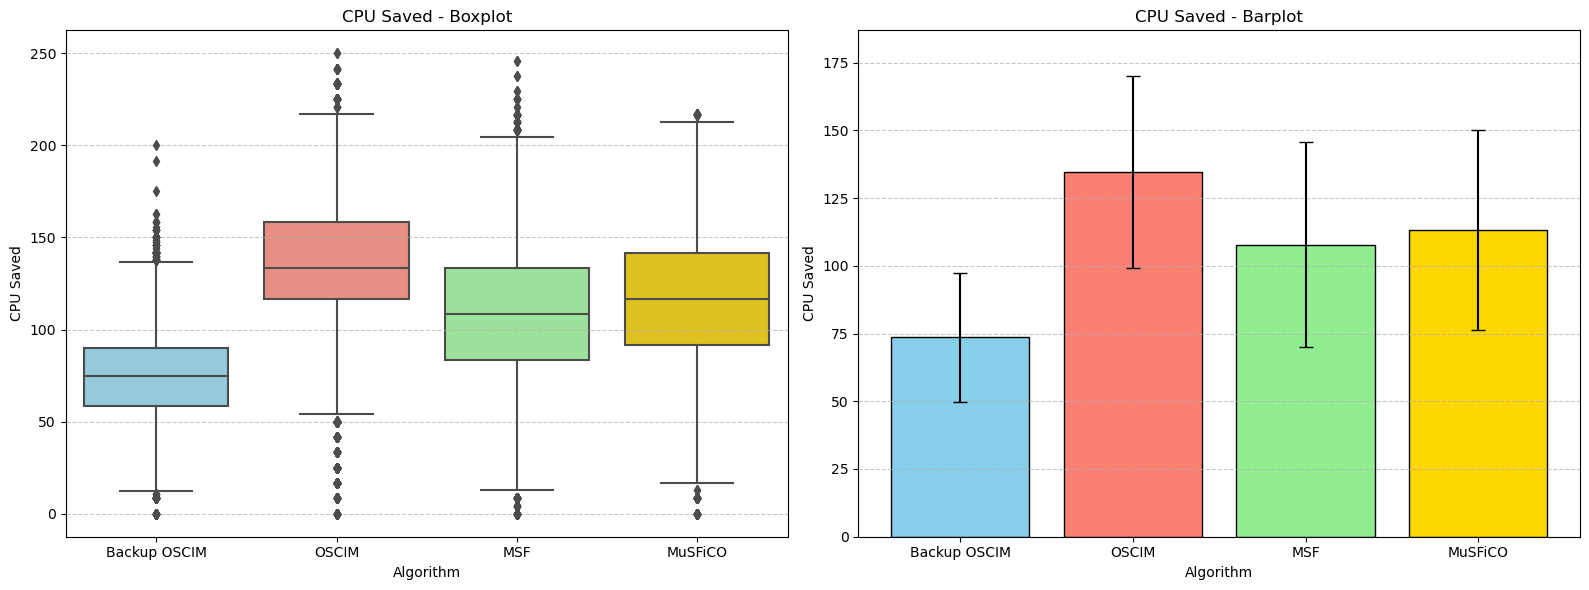

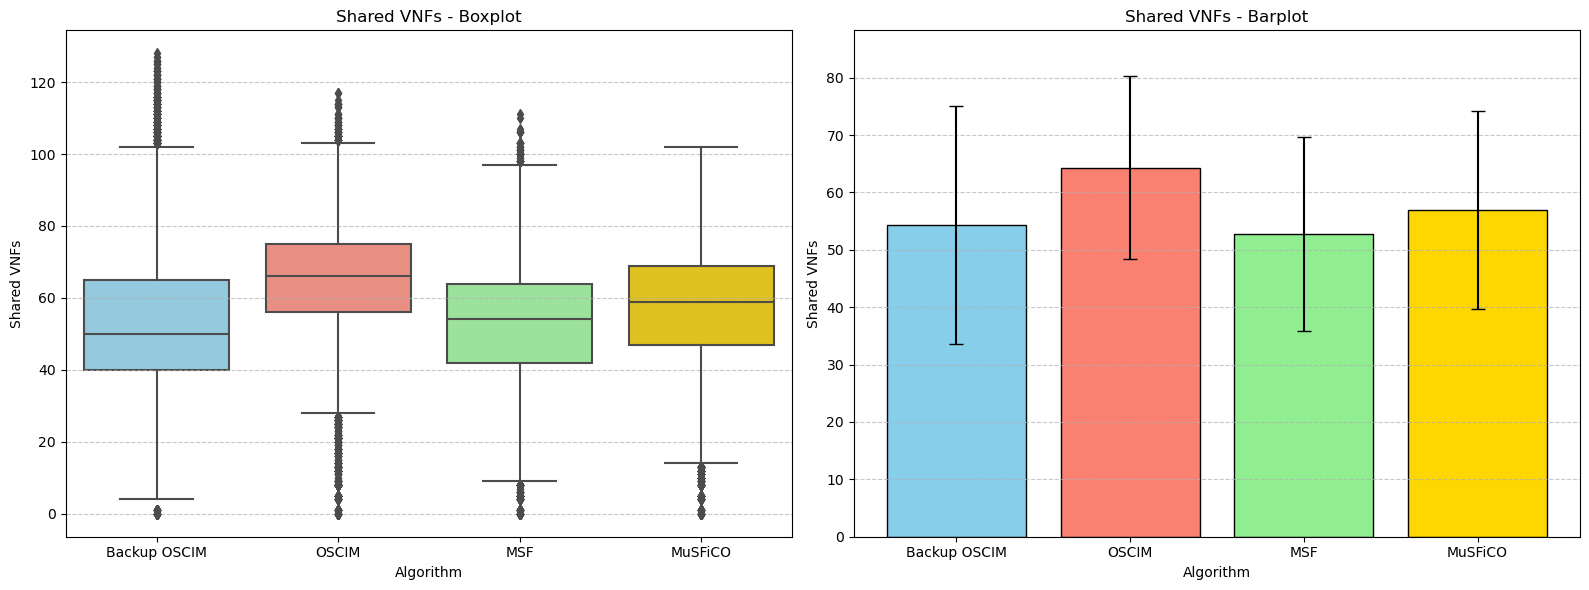

In [26]:
# Lista de métricas e seus títulos correspondentes
metrics = [
    ('cpu_saved', 'CPU Saved'),
    ('shared_vnfs', 'Shared VNFs')
]

# Loop para gerar gráficos para cada métrica
for metric, title in metrics:
    boxplot_filename = f'{metric}_boxplot.pdf'
    barplot_filename = f'{metric}_barplot.pdf'
    
    plot_metric_by_algorithm(non_backup_sfcs, metric, title, boxplot_filename, barplot_filename)

# Gráficos em relação ao número de usuários

In [27]:
import matplotlib.pyplot as plt

def plot_smoothed_metric(df, window=20, column_user='users', column_metric='latency', 
                         column_algorithm='algorithm', metric_label='Latência (ms)', 
                         title='Latência por Quantidade de Usuários', figsize=(8,6)):
    """
    Aplica a média móvel para suavizar os dados e cria um gráfico por algoritmo.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame contendo as colunas para o algoritmo, usuários e a métrica a ser suavizada.
    window (int): Tamanho da janela para a média móvel. O padrão é 20.
    column_user (str): Nome da coluna que representa a quantidade de usuários.
    column_metric (str): Nome da coluna que representa a métrica a ser suavizada (ex: 'latency').
    column_algorithm (str): Nome da coluna que representa os algoritmos.
    metric_label (str): Rótulo para o eixo Y (métrica).
    title (str): Título do gráfico.
    figsize (tuple): Tamanho da figura (largura, altura).
    
    Retorna:
    Um gráfico da métrica suavizada por quantidade de usuários.
    """
    # Aplicar média móvel para suavizar as curvas
    df['smoothed_metric'] = df.groupby(column_algorithm)[column_metric].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    
    # Criar o gráfico com a média móvel
    plt.figure(figsize=figsize)
    
    # Agrupar por 'algorithm' e plotar para cada um, com a média móvel aplicada
    for algorithm, group in df.groupby(column_algorithm):
        plt.plot(group[column_user], group['smoothed_metric'], linestyle='-', label=algorithm)
    
    # Adicionar título e rótulos aos eixos
    plt.title(title, fontsize=14)
    plt.xlabel('Quantidade de Usuários', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    
    # Adicionar legenda
    plt.legend(title="Algoritmo")
    
    # Exibir o gráfico com grid
    plt.grid(True)
    plt.show()


In [28]:
non_backup_sfcs

,time_seconds,cpu_utilization,bandwidth_utilization,latency,decision_time_ms,success,sfc_id,crash_moment,recovery_time,sfc_recovered,...,running_sessions,users_crashed,latency_diff,wait_time,cpu_saved,shared_vnfs,users,algorithm,simulation,backup_sfc
0,0.0,0.0083,0.0009,1.0,7.579,1,sfc_cache_p1_1,0,NaN,NaN,...,1,0,NaN,NaN,0.000000,0,1,Backup OSCIM,0,False
1,0.0,0.0258,0.0028,1.0,3.834,1,sfc_unique_p1_1,0,NaN,NaN,...,1,0,NaN,NaN,0.000000,1,1,Backup OSCIM,0,False
2,0.1,0.0272,0.0037,1.0,2.704,1,sfc_cache_p2_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,4,2,Backup OSCIM,0,False
3,0.1,0.0447,0.0055,1.0,2.706,1,sfc_unique_p2_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,5,2,Backup OSCIM,0,False
4,0.1,0.0531,0.0074,2.0,2.677,1,sfc_cache_p3_1,0,NaN,NaN,...,1,0,NaN,NaN,8.333333,5,3,Backup OSCIM,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,996.7,0.3804,0.2009,1.0,69.994,1,sfc_unique_p2_50,0,NaN,NaN,...,6,4,NaN,NaN,79.333333,46,247,MuSFiCO,29,False
736,996.8,0.3816,0.2018,1.0,64.100,1,sfc_cache_p3_50,0,NaN,NaN,...,6,4,NaN,NaN,87.666667,49,248,MuSFiCO,29,False
737,997.0,0.3749,0.1917,1.0,92.891,1,sfc_unique_p3_50,0,NaN,NaN,...,5,4,NaN,NaN,87.666667,50,248,MuSFiCO,29,False
738,997.1,0.3760,0.1926,1.0,63.688,1,sfc_cache_p4_50,0,NaN,NaN,...,5,4,NaN,NaN,96.000000,53,249,MuSFiCO,29,False


In [29]:
def calculate_mean(group):
    return group.mean()

# Agrupar o DataFrame por 'algorithm' e 'users' e calcular a média da coluna 'success'
succes_users = non_backup_sfcs.groupby(['algorithm', 'users'])['success'].mean().reset_index()
# Exibir o DataFrame resultante com as médias
df_succes_users_sfcs = succes_users[['algorithm', 'users', 'success']]
# Converter a coluna 'users' para inteiro
df_succes_users_sfcs['users'] = df_succes_users_sfcs['users'].astype(int)
df_succes_users_sfcs['success'] = df_succes_users_sfcs['success'] * 100

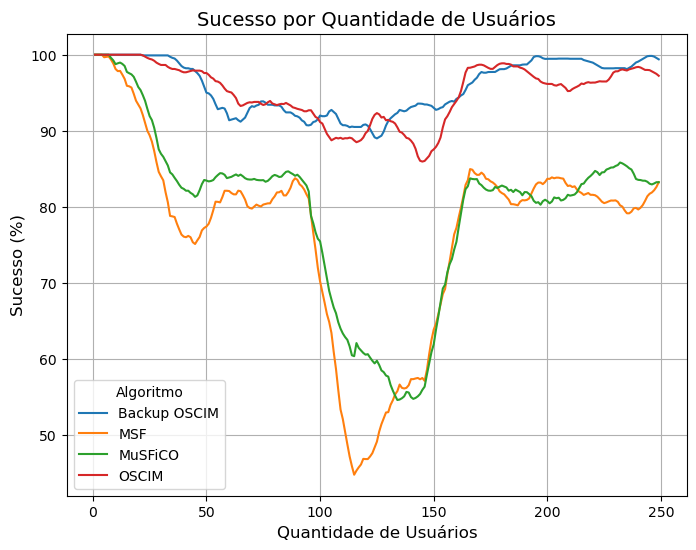

In [30]:
# Aplicar média móvel para suavizar as curvas
df_succes_users_sfcs['smoothed_success'] = df_succes_users_sfcs.groupby('algorithm')['success'].transform(lambda x: x.rolling(window=20, min_periods=1).mean())

# Criar o gráfico com a média móvel
plt.figure(figsize=(8,6))

# Agrupar por 'algorithm' e plotar para cada um, com a média móvel aplicada
for algorithm, group in df_succes_users_sfcs.groupby('algorithm'):
    plt.plot(group['users'], group['smoothed_success'], linestyle='-', label=algorithm)

# Adicionar título e rótulos aos eixos
plt.title('Sucesso por Quantidade de Usuários', fontsize=14)
plt.xlabel('Quantidade de Usuários', fontsize=12)
plt.ylabel('Sucesso (%)', fontsize=12)

# Adicionar legenda
plt.legend(title="Algoritmo")

# Exibir o gráfico com grid
plt.grid(True)
plt.show()


In [31]:
latency_mean_values = non_backup_sfcs.groupby(['algorithm', 'users'])['latency'].mean().reset_index()
df_latency_sfcs = latency_mean_values[['algorithm', 'latency','users']]
df_latency_sfcs['users'] = df_latency_sfcs['users'].astype(int)
df_latency_sfcs.dropna(inplace=True)
#plot_metric_by_algorithm(df_latency_sfcs, 'latency', 'latency', 'latency_boxplot.pdf', 'latency_barplot.pdf')

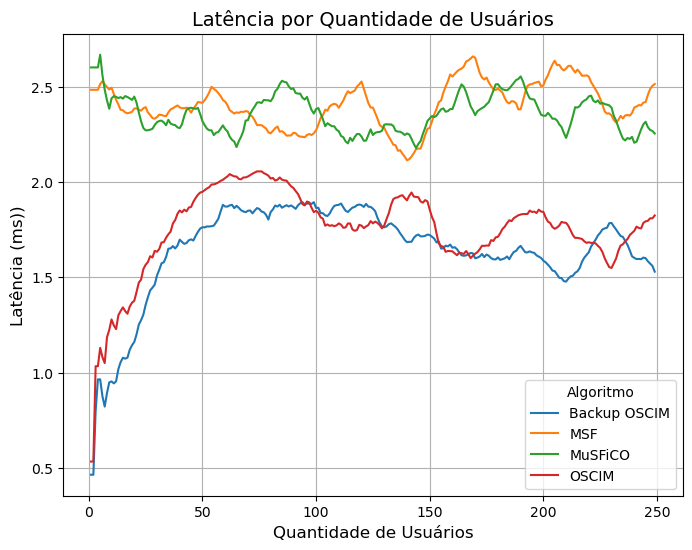

In [32]:
# Aplicar média móvel para suavizar as curvas
df_latency_sfcs['smoothed_latency'] = df_latency_sfcs.groupby('algorithm')['latency'].transform(lambda x: x.rolling(window=20, min_periods=1).mean())

# Criar o gráfico com a média móvel
plt.figure(figsize=(8,6))

# Agrupar por 'algorithm' e plotar para cada um, com a média móvel aplicada
for algorithm, group in df_latency_sfcs.groupby('algorithm'):
    plt.plot(group['users'], group['smoothed_latency'], linestyle='-', label=algorithm)

# Adicionar título e rótulos aos eixos
plt.title('Latência por Quantidade de Usuários', fontsize=14)
plt.xlabel('Quantidade de Usuários', fontsize=12)
plt.ylabel('Latência (ms))', fontsize=12)

# Adicionar legenda
plt.legend(title="Algoritmo")

# Exibir o gráfico com grid
plt.grid(True)
plt.show()

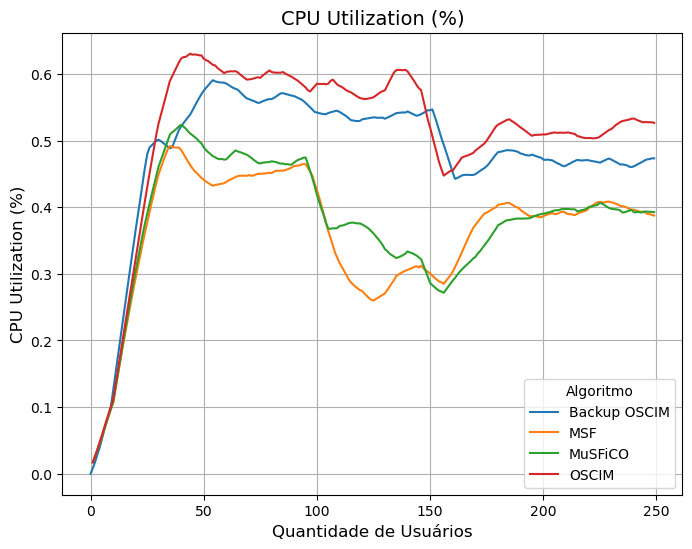

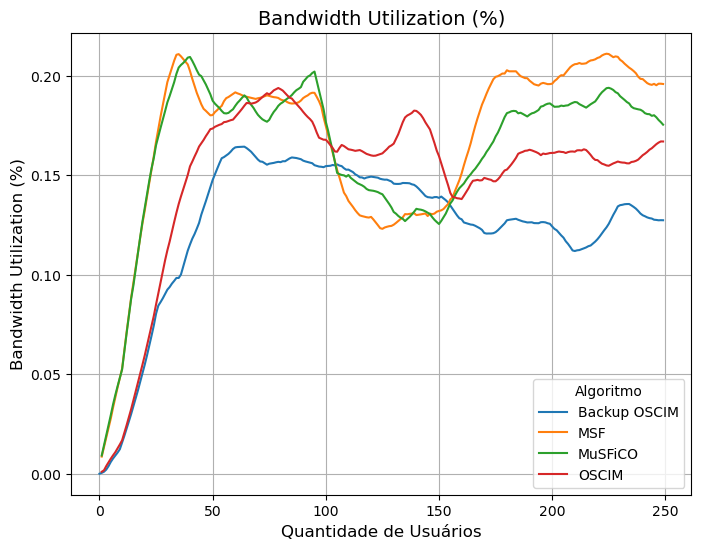

In [33]:
consume_metrics = concatenate_simulation_data[['users','cpu_utilization', 'bandwidth_utilization','cpu_saved','shared_vnfs','simulation','decision_time_ms','algorithm']]

df_consume_metrics = consume_metrics.groupby(['algorithm','users']).mean().reset_index()

# Lista de métricas e seus títulos correspondentes
metrics = [
    ('cpu_utilization', 'CPU Utilization (%)'),
    ('bandwidth_utilization', 'Bandwidth Utilization (%)')
]

# Loop para gerar gráficos para cada métrica
for metric, title in metrics:    
     plot_smoothed_metric(df_consume_metrics, window=10, column_user='users', column_metric=metric, 
                     column_algorithm='algorithm', metric_label=title, 
                     title=title, figsize=(8,6))